## Link for data in Kaggel:  [fruad Detection data](https://www.kaggle.com/datasets/kartik2112/fraud-detection)

## Dataset Columns Description

This dataset contains credit card transaction records, customer demographic information, merchant details, geographic attributes, and the fraud label. Each row represents a single transaction.

| Column Name | Description |
|------------|-------------|
| `Unnamed: 0` | Auto-generated row index from the original CSV file. It is typically unnecessary for analysis and can be removed. |
| `trans_date_trans_time` | Date and exact time when the transaction occurred. Useful for extracting temporal features such as hour, day, month, or weekday. |
| `cc_num` | Unique credit card number associated with the customer. Primarily an identifier and usually excluded from predictive modeling. |
| `merchant` | Name or identifier of the merchant where the transaction was made. Can be useful for behavioral or merchant-level fraud patterns. |
| `category` | Type of transaction or purchase category (e.g., grocery, travel, shopping). Important categorical feature for spending behavior analysis. |
| `amt` | Transaction amount in monetary units. One of the most important numerical features for fraud detection. |
| `first` | Customer's first name. Personal identifier with limited analytical value. Usually removed for privacy and modeling purposes. |
| `last` | Customer's last name. Personal identifier with limited analytical value. Usually removed for privacy and modeling purposes. |
| `gender` | Customer gender. Can be used as a demographic feature if relevant. |
| `street` | Street address of the customer. Primarily location detail; often excluded due to high uniqueness and privacy concerns. |
| `city` | Customer city of residence. Useful for regional analysis and customer segmentation. |
| `state` | Customer state of residence. Can reveal geographic fraud trends. |
| `zip` | Postal ZIP code of the customer. Useful for geographic clustering or regional patterns. |
| `lat` | Latitude coordinate of the customer's location. Can be used in spatial analysis. |
| `long` | Longitude coordinate of the customer's location. Can be used in spatial analysis. |
| `city_pop` | Population of the customer’s city. May indicate urban vs rural transaction behavior. |
| `job` | Customer occupation. Can be useful for demographic and behavioral profiling. |
| `dob` | Customer date of birth. Can be transformed into age, which is more useful analytically. |
| `trans_num` | Unique transaction identifier. Mainly used for record tracking and usually removed during modeling. |
| `unix_time` | Transaction timestamp in Unix format (seconds since epoch). Useful for time-series processing. |
| `merch_lat` | Latitude coordinate of the merchant location. Useful for calculating distance between customer and merchant. |
| `merch_long` | Longitude coordinate of the merchant location. Useful for calculating distance between customer and merchant. |
| `is_fraud` | Target variable indicating whether the transaction is fraudulent (`1`) or legitimate (`0`). |


In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
)
import warnings
warnings.filterwarnings('ignore')

In [2]:
# 1. Load Raw Data
df = pd.read_csv("fraudTrain_noisy_dataset.csv")
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [3]:
print("Original Shape:", df.shape)
print("\nMissing Values Before Cleaning:\n")
print(df.isnull().sum())

Original Shape: (1297675, 23)

Missing Values Before Cleaning:

Unnamed: 0                  0
trans_date_trans_time       0
cc_num                      0
merchant                    0
category                    0
amt                      6492
first                       0
last                        0
gender                      0
street                      0
city                        0
state                       0
zip                         0
lat                         0
long                        0
city_pop                    0
job                         0
dob                         0
trans_num                   0
unix_time                   0
merch_lat                   0
merch_long                  0
is_fraud                    0
dtype: int64


## Data Cleaning 

In [4]:
# 2. Remove Duplicate Rows
duplicates = df.duplicated().sum()
print("\nNumber of Duplicate Rows:", duplicates)

df = df.drop_duplicates()

print("Shape After Removing Duplicates:", df.shape)


Number of Duplicate Rows: 1000
Shape After Removing Duplicates: (1296675, 23)


In [5]:
# 3. Fix Data Types
# Convert date columns into datetime

df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'], errors='coerce')
df['dob'] = pd.to_datetime(df['dob'], errors='coerce')

### Missing Value Imputation for `amt`

Missing values in the `amt` column were handled using **median imputation grouped by transaction category**.  

This approach was selected because transaction amounts vary significantly across categories (e.g., grocery, travel, shopping), so filling missing values using the median within each category preserves more realistic spending patterns.  

The **median** was preferred over the mean because it is more robust to outliers and extreme transaction amounts, which are common in financial data.  

Any remaining missing values were filled using the overall median of the `amt` column as a fallback strategy.

In [6]:
# 4. Handle Missing Values
# amt column → fill missing values using median by category
df['amt'] = df.groupby('category')['amt'].transform(
    lambda x: x.fillna(x.median())
)

# If any still missing → fill global median
df['amt'] = df['amt'].fillna(df['amt'].median())

In [7]:
# 5. Handle Inconsistent Entries

#  convert all category text to lowercase
df['category'] = df['category'].str.lower().str.strip()

#  standardize gender
df['gender'] = df['gender'].str.upper().str.strip()

In [8]:
# 6. Remove Unnecessary Columns
drop_cols = ['Unnamed: 0', 'first', 'last', 'street', 'trans_num']

df.drop(columns=drop_cols, inplace=True, errors='ignore')

In [9]:
# 7. Pivot Table (Structurally Appropriate)
# Average Transaction Amount by Category and Fraud Class
pivot_table = pd.pivot_table(
    df,
    values='amt',
    index='category',
    columns='is_fraud',
    aggfunc='mean'
)

print("\nPivot Table:\n")
print(pivot_table)


Pivot Table:

is_fraud                 0           1
category                              
entertainment    63.055108  503.535579
food_dining      50.916577  120.076954
gas_transport    63.665278   12.635987
grocery_net      53.774618   12.162836
grocery_pos     114.140850  310.276087
health_fitness   54.180439   20.248421
home             57.904543  257.432626
kids_pets        57.574462   18.241255
misc_net         70.059013  793.360503
misc_pos         62.117596  218.139840
personal_care    47.946180   26.170545
shopping_net     71.844576  995.776778
shopping_pos     73.697334  874.904496
travel          111.281095    9.064569


In [10]:
# 8. Final Check
print("\nFinal Shape:", df.shape)

print("\nMissing Values After Cleaning:\n")
print(df.isnull().sum())

print("\nData Types:\n")
print(df.dtypes)


Final Shape: (1296675, 18)

Missing Values After Cleaning:

trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
gender                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

Data Types:

trans_date_trans_time    datetime64[us]
cc_num                            int64
merchant                            str
category                            str
amt                             float64
gender                              str
city                                str
state                               str
zip                               int64
lat                             float64
long                      

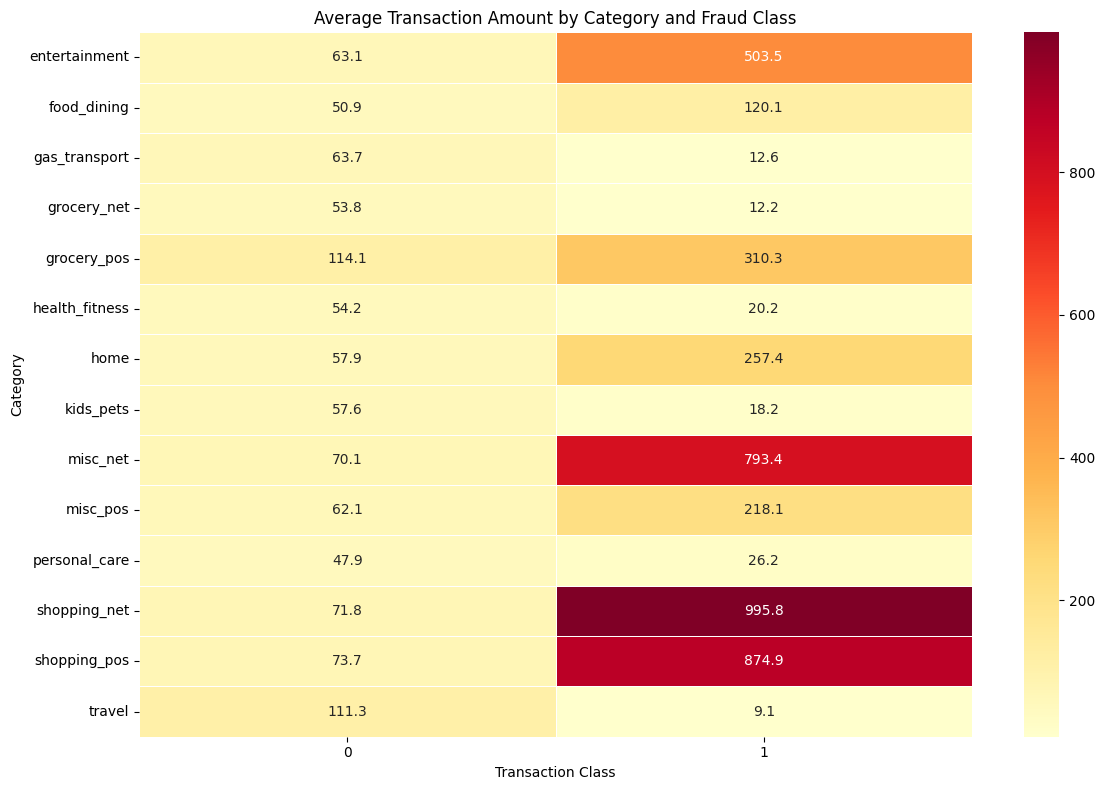

In [11]:
# Heatmap Visualization
# ------------------------------------------------------------
plt.figure(figsize=(12,8))

sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title("Average Transaction Amount by Category and Fraud Class")
plt.xlabel("Transaction Class")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

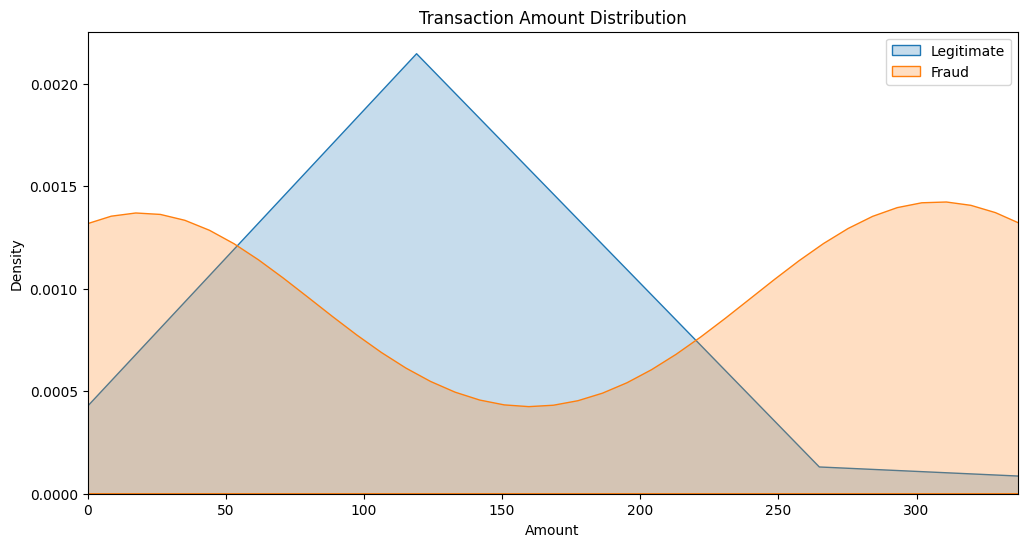

In [12]:
# 2. Transaction Amount Distribution (Fraud vs Legit)
# ============================================================
plt.figure(figsize=(12,6))

sns.kdeplot(
    data=df[df['is_fraud']==0],
    x='amt',
    label='Legitimate',
    fill=True,
    common_norm=False
)

sns.kdeplot(
    data=df[df['is_fraud']==1],
    x='amt',
    label='Fraud',
    fill=True,
    common_norm=False
)

plt.xlim(0, df['amt'].quantile(0.98))
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Density")
plt.legend()
plt.show()

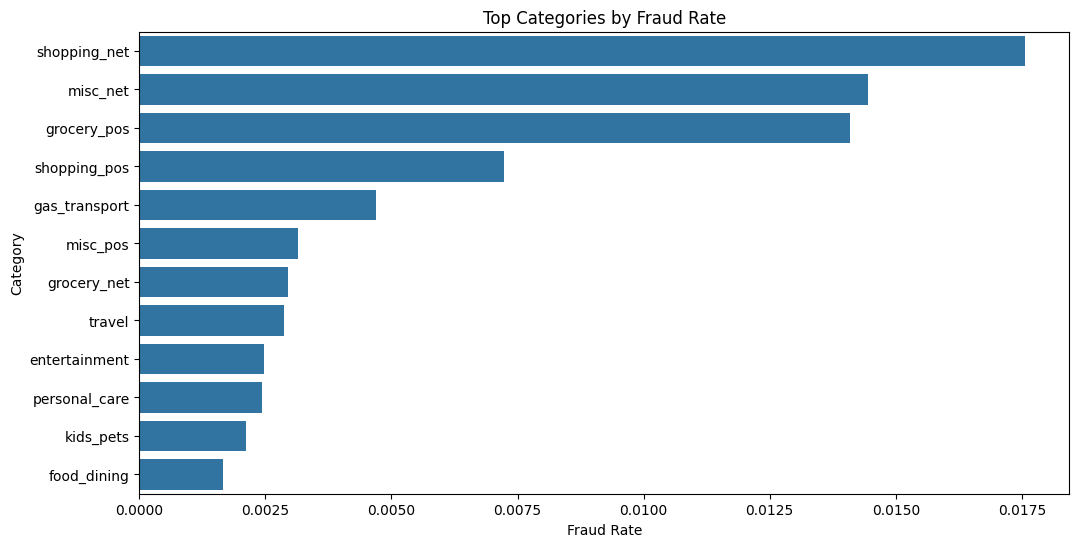

In [13]:
# Top Categories By Fraud Rate
cat_fraud = (
    df.groupby('category')['is_fraud']
    .mean()
    .sort_values(ascending=False)
    .head(12)
)

plt.figure(figsize=(12,6))
sns.barplot(x=cat_fraud.values, y=cat_fraud.index)
plt.title("Top Categories by Fraud Rate")
plt.xlabel("Fraud Rate")
plt.ylabel("Category")
plt.show()

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 18 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   trans_date_trans_time  1296675 non-null  datetime64[us]
 1   cc_num                 1296675 non-null  int64         
 2   merchant               1296675 non-null  str           
 3   category               1296675 non-null  str           
 4   amt                    1296675 non-null  float64       
 5   gender                 1296675 non-null  str           
 6   city                   1296675 non-null  str           
 7   state                  1296675 non-null  str           
 8   zip                    1296675 non-null  int64         
 9   lat                    1296675 non-null  float64       
 10  long                   1296675 non-null  float64       
 11  city_pop               1296675 non-null  int64         
 12  job                    1296675 non-null

In [15]:
numeric_columns = [ 'cc_num', 'amt',
       'zip', 'lat', 'long', 'city_pop',
        'unix_time', 'merch_lat', 'merch_long']

These outliers were retained because they represent important features and potentially valuable fraud-related patterns that should not be removed


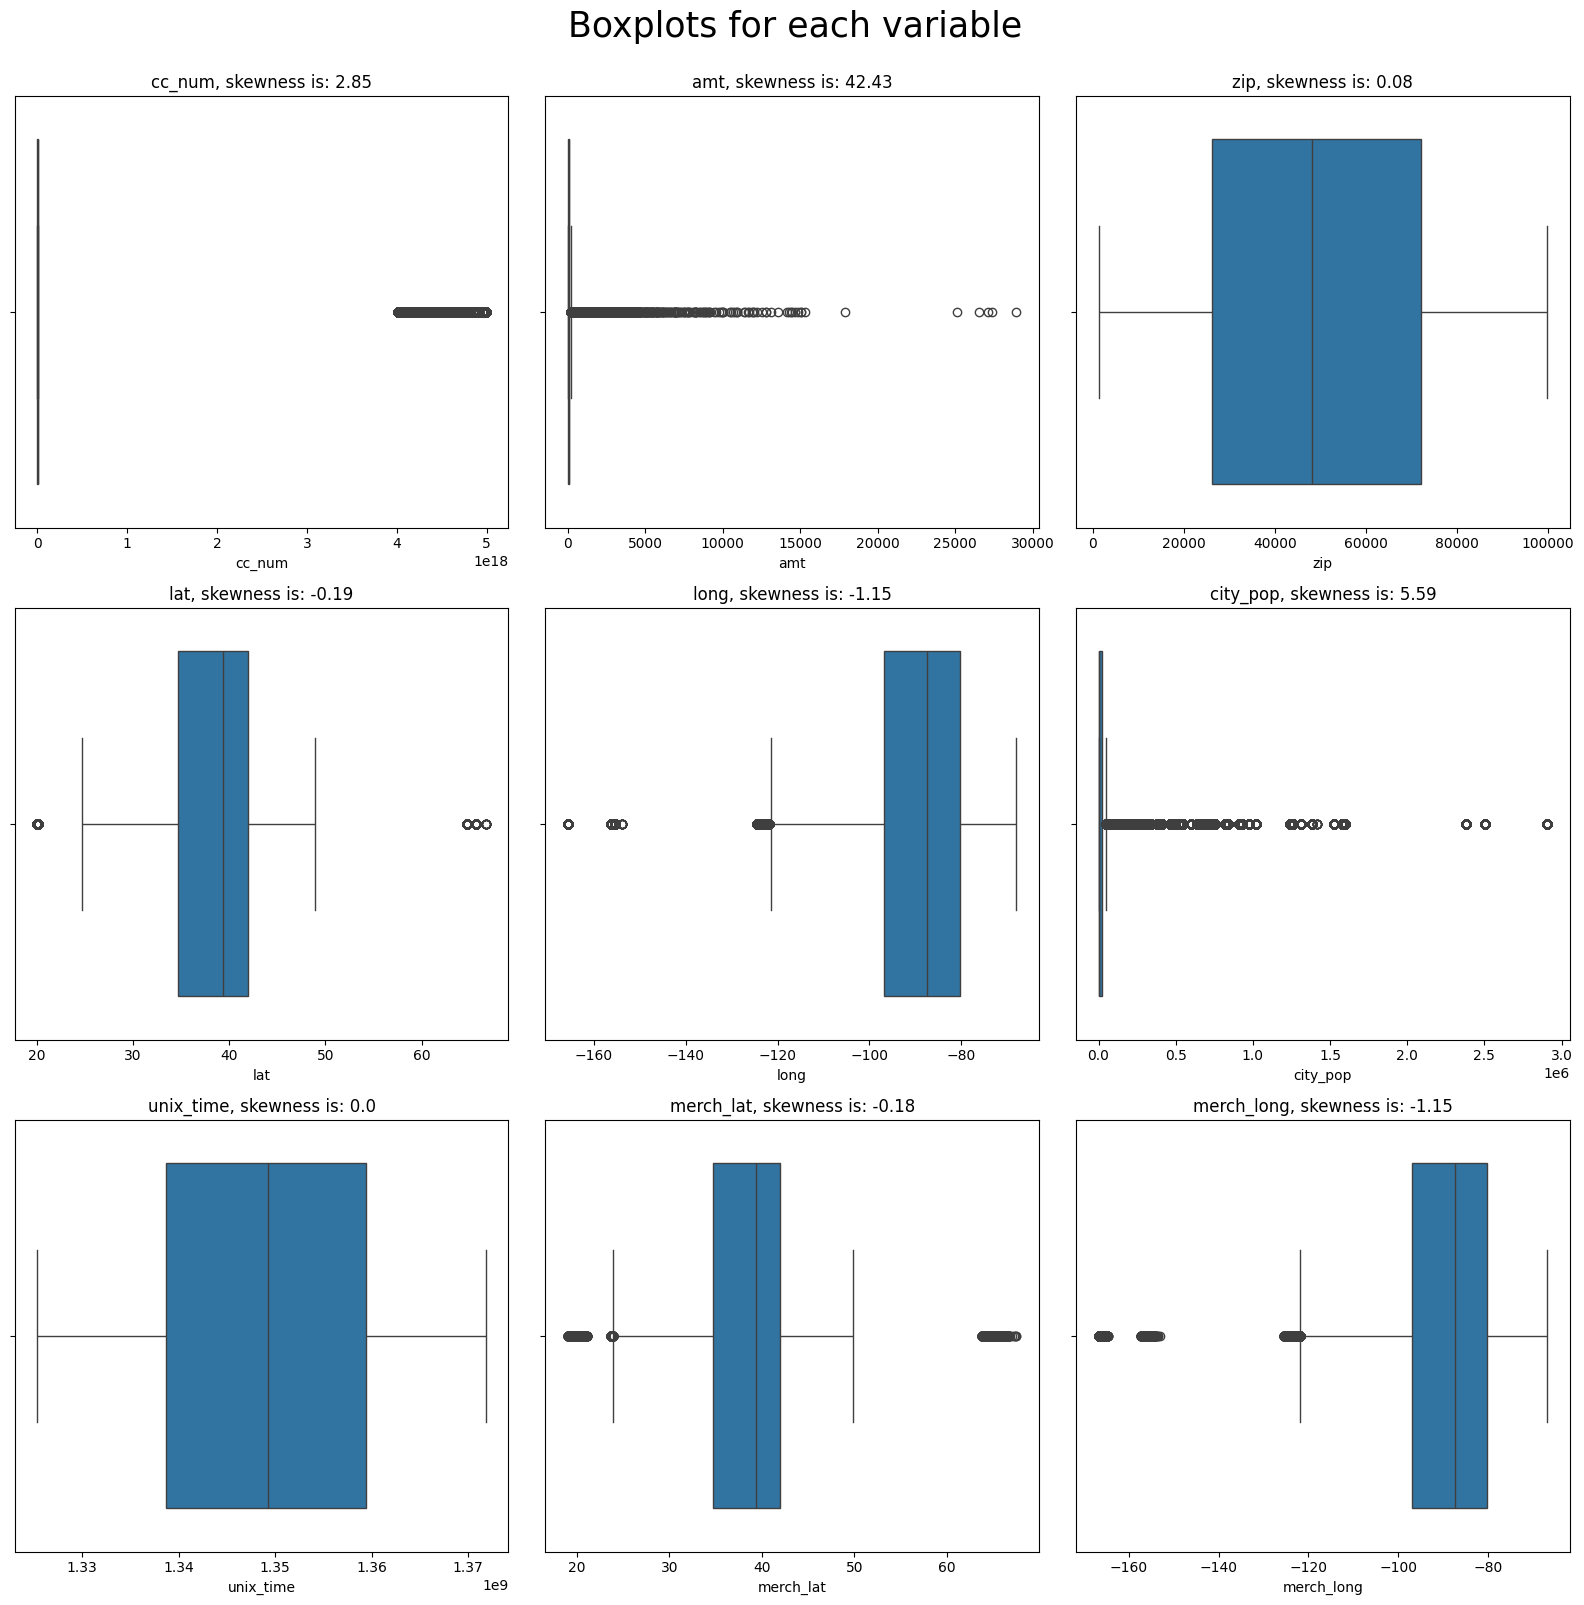

In [16]:
## Outliers
# checking boxplots
def boxplots_custom(dataset, columns_list, rows, cols, suptitle):
    fig, axs = plt.subplots(rows, cols, sharey=True, figsize=(16,16))
    fig.suptitle(suptitle,y=1, size=25)
    axs = axs.flatten()
    for i, data in enumerate(columns_list):
        sns.boxplot(data=dataset[data], orient='h', ax=axs[i])
        axs[i].set_title(data + ', skewness is: '+str(round(dataset[data].skew(axis = 0, skipna = True),2)))
        
boxplots_custom(dataset=df, columns_list=numeric_columns, rows=3, cols=3, suptitle='Boxplots for each variable')
plt.tight_layout()
print("These outliers were retained because they represent important features and potentially valuable fraud-related patterns that should not be removed")

## Feature Extraction 

In [17]:
# ── 3.1  Transaction Hour / Day-of-Week / Cyclical encoding ──────────────────────────────────
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['trans_hour']   = df['trans_date_trans_time'].dt.hour
df['trans_dow']    = df['trans_date_trans_time'].dt.dayofweek   # 0=Mon
df['is_weekend']   = (df['trans_dow'] >= 5).astype(int)
df['is_night']     = ((df['trans_hour'] >= 22) | (df['trans_hour'] <= 5)).astype(int)

# # Cyclical encoding 
df['hour_sin'] = np.sin(2 * np.pi * df['trans_hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['trans_hour'] / 24)

df['dow_sin'] = np.sin(2 * np.pi * df['trans_dow'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['trans_dow'] / 7)



print("\n[3.1] Temporal features extracted: trans_hour, trans_dow, is_weekend, is_night") 
print("  WHY: Fraud patterns are often time-dependent (e.g., night-time or weekend behavior).")
print("       However, raw time features (hour/day) are cyclic in nature, meaning")
print("       the end of the cycle is close to the beginning (e.g., 23:00 ≈ 00:00, Sunday ≈ Monday).")
print("       Standard numeric encoding fails to capture this relationship.")
print("  CYCLICAL ENCODING: We use sine and cosine transforms to map time into a circular space,")
print("       preserving this continuity so that the model understands temporal proximity correctly.")
print("  REVEALS: Time-of-day and weekday cyclic patterns that may correlate with fraud risk.")


[3.1] Temporal features extracted: trans_hour, trans_dow, is_weekend, is_night
  WHY: Fraud patterns are often time-dependent (e.g., night-time or weekend behavior).
       However, raw time features (hour/day) are cyclic in nature, meaning
       the end of the cycle is close to the beginning (e.g., 23:00 ≈ 00:00, Sunday ≈ Monday).
       Standard numeric encoding fails to capture this relationship.
  CYCLICAL ENCODING: We use sine and cosine transforms to map time into a circular space,
       preserving this continuity so that the model understands temporal proximity correctly.
  REVEALS: Time-of-day and weekday cyclic patterns that may correlate with fraud risk.


In [18]:
# ── 3.2  Customer Age ────────────────────────────────────────────────────
df["age"] = (
    (df["trans_date_trans_time"] - df["dob"]).dt.days / 365.25
).astype(int)

print("  WHY: Older or younger cardholders may show different vulnerability profiles.")
print("  REVEALS: Age group risk segmentation.")

  WHY: Older or younger cardholders may show different vulnerability profiles.
  REVEALS: Age group risk segmentation.


In [19]:
# ── 3.3  Geographic Distance (card-holder → merchant) ────────────────────
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
 
df['geo_distance'] = haversine(df['lat'], df['long'], df['merch_lat'], df['merch_long'])
 
print("\n[3.3] Haversine distance (km) extracted: geo_distance")
print("  WHY: A purchase hundreds of km from the cardholder's home is a classic")
print("       fraud signal; raw lat/long pairs cannot express this directly.")
print("  REVEALS: How far a transaction is from the cardholder's typical location.")


[3.3] Haversine distance (km) extracted: geo_distance
  WHY: A purchase hundreds of km from the cardholder's home is a classic
       fraud signal; raw lat/long pairs cannot express this directly.
  REVEALS: How far a transaction is from the cardholder's typical location.


In [20]:
# ── 3.4  Log-Amount ──────────────────────────────────────────────────────
df['log_amt'] = np.log1p(df['amt'])
 
print("\n[3.4] Log-transformed amount: log_amt")
print("  WHY: Transaction amounts are heavily right-skewed; log-transform reduces")
print("       dominance of extreme values and linearises relationships.")
print("  REVEALS: Relative magnitude differences more clearly than raw amt.")


[3.4] Log-transformed amount: log_amt
  WHY: Transaction amounts are heavily right-skewed; log-transform reduces
       dominance of extreme values and linearises relationships.
  REVEALS: Relative magnitude differences more clearly than raw amt.


In [21]:
# ── 3.5  City Population Bins ────────────────────────────────────────────
df['pop_bin'] = pd.cut(df['city_pop'],
                        bins=[0, 1000, 10_000, 100_000, np.inf],
                        labels=[0, 1, 2, 3]).astype(int)
 
print("\n[3.5] Population bin encoded: pop_bin (0=rural … 3=urban)")
print("  WHY: Rural vs urban fraud rates differ; continuous city_pop has diminishing")
print("       marginal information past a certain size.")
print("  REVEALS: Urban-density risk groupings.")


[3.5] Population bin encoded: pop_bin (0=rural … 3=urban)
  WHY: Rural vs urban fraud rates differ; continuous city_pop has diminishing
       marginal information past a certain size.
  REVEALS: Urban-density risk groupings.


In [22]:
# ─ 3.6  Interaction Feature (amt * distance) ────────────────────────────────────────────
df['log_distance'] = np.log1p(df['geo_distance'])
df['amt_distance_interaction'] = df['log_amt'] * df['log_distance']

In [23]:
# ── 3.7  Drop columns that are redundant or leak into target ────────────────────────────────────────────
drop_cols = [
    "dob",                    # replaced by age
    "unix_time",              # redundant with datetime
    "zip",                    # covered by lat/long
    "city",                   # too many unique values; use state + pop instead
    "merch_lat",              # absorbed into distance_km
    "merch_long",
    "merchant",
    "job"
]
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

In [24]:
from sklearn.model_selection import train_test_split
# CELL 8 — Train / Val / Test split  (stratified)
# ============================================================
X = df.drop(columns=["is_fraud"])
y = df["is_fraud"]
 
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)
 
print(f"Train : {X_train.shape}  fraud rate: {y_train.mean():.3%}")
print(f"Val   : {X_val.shape}   fraud rate: {y_val.mean():.3%}")
print(f"Test  : {X_test.shape}  fraud rate: {y_test.mean():.3%}")

Train : (907672, 23)  fraud rate: 0.579%
Val   : (194501, 23)   fraud rate: 0.579%
Test  : (194502, 23)  fraud rate: 0.579%


In [25]:
# ── 3.10 check the same features in Train / Val / Test split to prevent Error in model ────────────────────────────────────────────

print(X_train.columns)
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)
print(X_train.columns == X_test.columns)
print(X_train.columns == X_val.columns)

Index(['trans_date_trans_time', 'cc_num', 'category', 'amt', 'gender', 'state',
       'lat', 'long', 'city_pop', 'trans_hour', 'trans_dow', 'is_weekend',
       'is_night', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'age',
       'geo_distance', 'log_amt', 'pop_bin', 'log_distance',
       'amt_distance_interaction'],
      dtype='str')
(907672, 23)
(194501, 23)
(194502, 23)
[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True]
[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True]


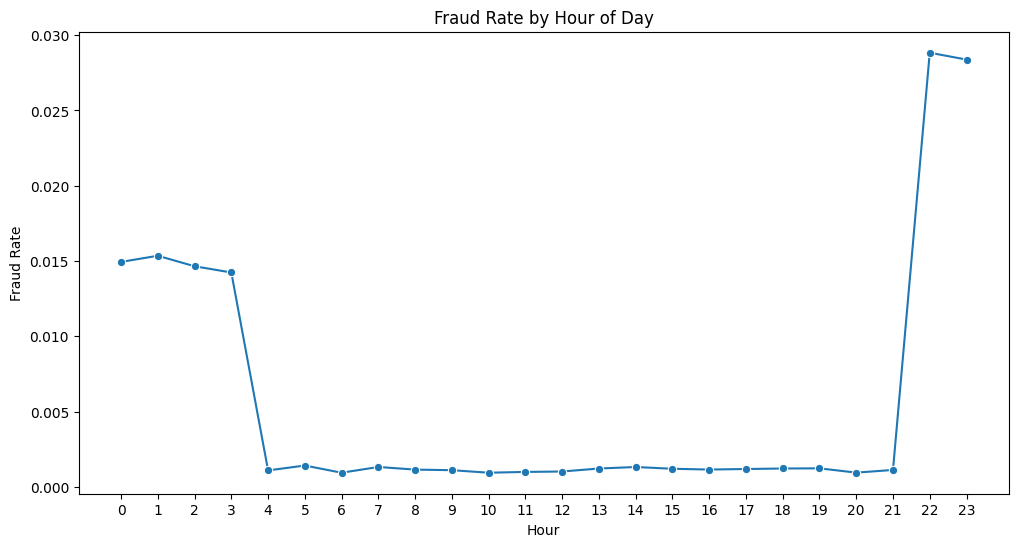

In [26]:
# 3. Fraud Rate by Hour of Day
# ============================================================
hour_fraud = df.groupby('trans_hour')['is_fraud'].mean()

plt.figure(figsize=(12,6))
sns.lineplot(x=hour_fraud.index, y=hour_fraud.values, marker="o")
plt.title("Fraud Rate by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate")
plt.xticks(range(24))
plt.show()


## Feature Selection 

In [27]:
X_train.info()


<class 'pandas.DataFrame'>
Index: 907672 entries, 192318 to 33493
Data columns (total 23 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   trans_date_trans_time     907672 non-null  datetime64[us]
 1   cc_num                    907672 non-null  int64         
 2   category                  907672 non-null  str           
 3   amt                       907672 non-null  float64       
 4   gender                    907672 non-null  str           
 5   state                     907672 non-null  str           
 6   lat                       907672 non-null  float64       
 7   long                      907672 non-null  float64       
 8   city_pop                  907672 non-null  int64         
 9   trans_hour                907672 non-null  int32         
 10  trans_dow                 907672 non-null  int32         
 11  is_weekend                907672 non-null  int64         
 12  is_night      

In [28]:
# ── 4.0  Encode categoricals — fit on TRAIN, transform val & test ────────
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
CAT_COLS = ['gender', 'category', 'state']
encoders = {}
 
for col in CAT_COLS:
    le = LabelEncoder()
    X_train[col + '_enc'] = le.fit_transform(X_train[col].astype(str))
    X_val [col + '_enc'] = le.transform(X_val  [col].astype(str))
    X_test [col + '_enc'] = le.transform(X_test [col].astype(str))
    encoders[col] = le     # save for future inference
 
# Drop the raw string columns now that encoded versions exist
X_train = X_train.drop(columns=CAT_COLS)
X_val   = X_val.drop(columns=CAT_COLS)
X_test  = X_test.drop(columns=CAT_COLS)
 
print(f"[4.0] LabelEncoder fit on X_train only.")
print(f"      Encoded: {[c+'_enc' for c in CAT_COLS]}\n")

[4.0] LabelEncoder fit on X_train only.
      Encoded: ['gender_enc', 'category_enc', 'state_enc']



In [29]:
# ── 4.1  Feature pools ────────
NUM_FEATURES = [
    'amt', 
    'log_amt', 
    'geo_distance', 
    'age',
    'city_pop', 
    'trans_hour', 
    'trans_dow',
    'is_weekend', 
    'is_night', 
    'pop_bin',
    # New engineered features you added
    'log_distance',
    'amt_distance_interaction',
    # Cyclical features (very useful for fraud models)
    'hour_sin',
    'hour_cos',
    'dow_sin',
    'dow_cos'
]

CAT_FEATURES = [
    'gender_enc', 
    'category_enc', 
    'state_enc',
    'is_weekend', 
    'is_night', 
    'pop_bin'
]

# Remove duplicates while preserving order
ALL_FEATURES = list(dict.fromkeys(NUM_FEATURES + CAT_FEATURES))

# ── Select features ──────────────────────────────────────────────────────
X_train_new = X_train[ALL_FEATURES].copy()
X_val_new   = X_val[ALL_FEATURES].copy()
X_test_new  = X_test[ALL_FEATURES].copy()

print(f"Selected {len(ALL_FEATURES)} features for modeling:")
print(ALL_FEATURES)

Selected 19 features for modeling:
['amt', 'log_amt', 'geo_distance', 'age', 'city_pop', 'trans_hour', 'trans_dow', 'is_weekend', 'is_night', 'pop_bin', 'log_distance', 'amt_distance_interaction', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'gender_enc', 'category_enc', 'state_enc']


In [30]:
X_train_new.head()

,amt,log_amt,geo_distance,age,city_pop,trans_hour,trans_dow,is_weekend,is_night,pop_bin,log_distance,amt_distance_interaction,hour_sin,hour_cos,dow_sin,dow_cos,gender_enc,category_enc,state_enc
192318,199.87,5.302658,53.183930,43,4074,23,0,0,1,1,3.992384,21.170249,-2.588190e-01,0.965926,0.000000,1.000000,0,11,2
318906,13.65,2.684440,52.332727,63,263,12,6,1,0,0,3.976550,10.674812,1.224647e-16,-1.000000,-0.781831,0.623490,0,7,43
212432,47.98,3.891412,13.116747,92,4845,17,3,0,0,1,2.647362,10.301976,-9.659258e-01,-0.258819,0.433884,-0.900969,0,10,19
979043,157.10,5.063228,74.079720,34,224256,23,5,1,1,3,4.318550,21.865805,-2.588190e-01,0.965926,-0.974928,-0.222521,0,6,9
614236,111.12,4.719570,49.616931,43,324,23,1,0,1,0,3.924286,18.520942,-2.588190e-01,0.965926,0.781831,0.623490,0,5,14


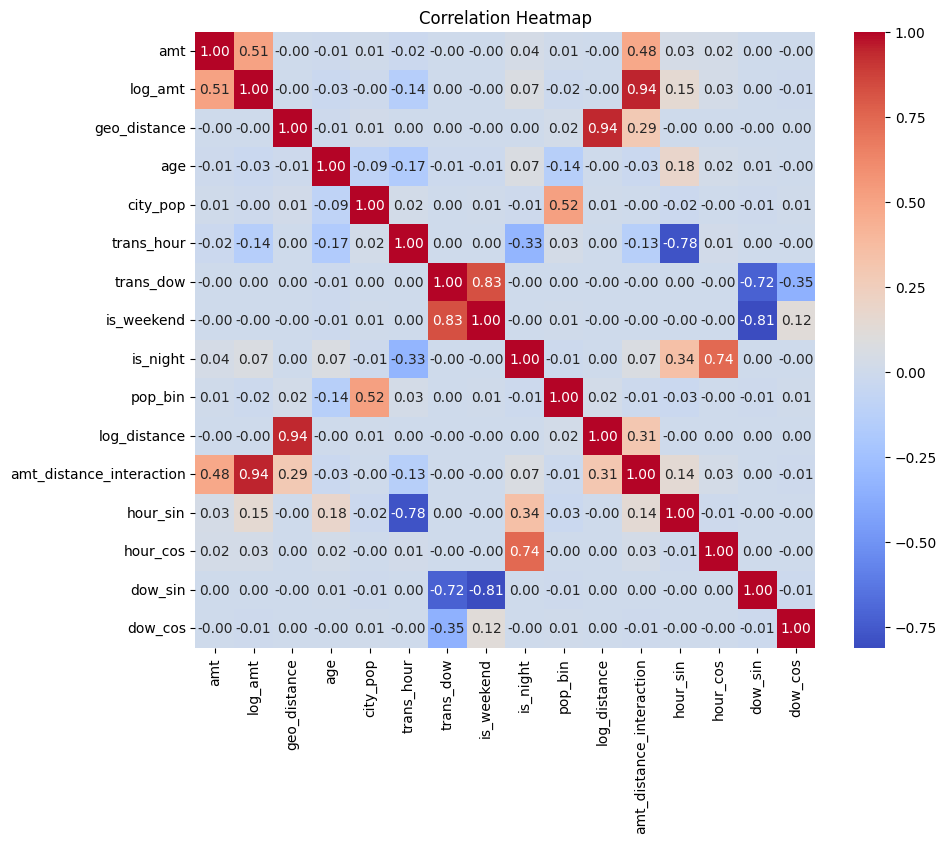

In [31]:
#correlation function to detect relationships between features 
corr = X_train_new[NUM_FEATURES].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# METHOD A — Mutual Information  (all features vs binary class)
#
# WHY CHOSEN: Non-parametric — captures linear AND non-linear dependencies.
# Works on numeric and encoded categorical features in one pass. No assumption
# about distributions. Best all-round ranking method for fraud data where
# relationships between features and the target may be complex.
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.feature_selection import chi2, f_classif, mutual_info_classif

print("── Method A: Mutual Information  (all features, fit on X_train_new) ────")
mi_scores = mutual_info_classif(X_train_new[ALL_FEATURES], y_train, random_state=42)
mi_df = (
    pd.DataFrame({
        'feature' : ALL_FEATURES,
        'MI_score': np.round(mi_scores, 6),
    })
    .sort_values('MI_score', ascending=False)
    .reset_index(drop=True)
)
print(mi_df.to_string(index=False))
mi_top = mi_df.loc[mi_df['MI_score'] > 0.001, 'feature'].tolist()
print(f"\n  -> MI > 0.001: {mi_top}\n")

── Method A: Mutual Information  (all features, fit on X_train_new) ────
                 feature  MI_score
              gender_enc  0.108294
              is_weekend  0.068287
                is_night  0.054882
                 dow_cos  0.046590
                 pop_bin  0.037226
               trans_dow  0.033744
                 dow_sin  0.029505
                hour_sin  0.019464
                hour_cos  0.018572
            category_enc  0.017859
                 log_amt  0.017335
                     amt  0.017293
              trans_hour  0.014833
amt_distance_interaction  0.010724
               state_enc  0.007037
                city_pop  0.004431
                     age  0.003699
            geo_distance  0.000000
            log_distance  0.000000

  -> MI > 0.001: ['gender_enc', 'is_weekend', 'is_night', 'dow_cos', 'pop_bin', 'trans_dow', 'dow_sin', 'hour_sin', 'hour_cos', 'category_enc', 'log_amt', 'amt', 'trans_hour', 'amt_distance_interaction', 'state_enc', 'city_pop

In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# METHOD B — ANOVA F-test  (numerical features vs binary class)
#
# WHY CHOSEN: Measures how well each continuous feature separates the fraud /
# non-fraud groups by comparing within-group vs between-group variance. Fast,
# produces interpretable p-values, ideal for the numeric features extracted
# in Step 3.  Limitation: assumes linear relationship; cannot assess categoricals.
# ─────────────────────────────────────────────────────────────────────────────
print("── Method b: ANOVA F-test  (numerical, fit on X_train_new) ─────────────")
f_scores, p_values = f_classif(X_train_new[NUM_FEATURES], y_train)
anova_df = (
    pd.DataFrame({
        'feature': NUM_FEATURES,
        'F_score': np.round(f_scores, 2),
        'p_value': p_values,
    })
    .sort_values('F_score', ascending=False)
    .reset_index(drop=True)
)
print(anova_df.to_string(index=False))
anova_top = anova_df.loc[anova_df['p_value'] < 0.05, 'feature'].tolist()
print(f"\n  -> Significant (p < 0.05): {anova_top}\n")

── Method b: ANOVA F-test  (numerical, fit on X_train_new) ─────────────
                 feature  F_score      p_value
                     amt 48997.93 0.000000e+00
                 log_amt 13164.56 0.000000e+00
amt_distance_interaction 11799.33 0.000000e+00
                is_night  7988.49 0.000000e+00
                hour_cos  5704.12 0.000000e+00
              trans_hour   200.33 1.789313e-45
                     age   137.04 1.186155e-31
                 dow_cos   120.61 4.660496e-28
                hour_sin    11.65 6.433921e-04
              is_weekend     9.71 1.833740e-03
                city_pop     4.98 2.564428e-02
                 pop_bin     4.30 3.816122e-02
               trans_dow     4.22 4.000384e-02
                 dow_sin     3.96 4.645933e-02
            log_distance     0.32 5.708611e-01
            geo_distance     0.02 8.761755e-01

  -> Significant (p < 0.05): ['amt', 'log_amt', 'amt_distance_interaction', 'is_night', 'hour_cos', 'trans_hour', 'age', 'dow_c

In [34]:
#Method C: Chi-Square Test  (categorical, fit on X_train)

print("── Method C: Chi-Square Test  (categorical, fit on X_train) ────────")
scaler = MinMaxScaler()
X_train_cat_scaled = scaler.fit_transform(X_train_new[CAT_FEATURES])   # fit + transform
X_val_cat_scaled   = scaler.transform(X_val_new  [CAT_FEATURES])        # transform only
X_test_cat_scaled  = scaler.transform(X_test_new [CAT_FEATURES])        # transform only
 
chi2_scores, chi2_p = chi2(X_train_cat_scaled, y_train)
chi2_df = (
    pd.DataFrame({
        'feature'   : CAT_FEATURES,
        'chi2_score': np.round(chi2_scores, 2),
        'p_value'   : chi2_p,
    })
    .sort_values('chi2_score', ascending=False)
    .reset_index(drop=True)
)
print(chi2_df.to_string(index=False))
chi2_top = chi2_df.loc[chi2_df['p_value'] < 0.05, 'feature'].tolist()
print(f"\n  -> Significant (p < 0.05): {chi2_top}\n")

── Method C: Chi-Square Test  (categorical, fit on X_train) ────────
     feature  chi2_score      p_value
    is_night     5542.68 0.000000e+00
category_enc       72.37 1.782317e-17
  gender_enc       31.49 2.009291e-08
  is_weekend        6.33 1.189341e-02
   state_enc        1.28 2.585878e-01
     pop_bin        1.27 2.594588e-01

  -> Significant (p < 0.05): ['is_night', 'category_enc', 'gender_enc', 'is_weekend']



In [35]:
## Comparision
print("=" * 70)
print("COMPARISON — Feature Selection Methods")
print("=" * 70)
 
anova_set = set(anova_top)
mi_set    = set(mi_top)
chi2_set  = set(chi2_top)
 
rows = []
for f in ALL_FEATURES:
    votes = sum([f in anova_set, f in mi_set, f in chi2_set])
    rows.append({
        'Feature'    : f,
        'ANOVA'      : 'Y' if f in anova_set else '-',
        'Mutual Info': 'Y' if f in mi_set    else '-',
        'Chi-Square' : 'Y' if f in chi2_set  else '-',
        'Votes'      : votes,
    })
 
comp_df = (
    pd.DataFrame(rows)
    .sort_values(['Votes', 'Feature'], ascending=[False, True])
    .reset_index(drop=True)
)
print(comp_df.to_string(index=False))
 
consensus = comp_df.loc[comp_df['Votes'] >= 2, 'Feature'].tolist()
print(f"\n  -> Consensus (>= 2 methods agree): {consensus}")
 

COMPARISON — Feature Selection Methods
                 Feature ANOVA Mutual Info Chi-Square  Votes
                is_night     Y           Y          Y      3
              is_weekend     Y           Y          Y      3
                     age     Y           Y          -      2
                     amt     Y           Y          -      2
amt_distance_interaction     Y           Y          -      2
            category_enc     -           Y          Y      2
                city_pop     Y           Y          -      2
                 dow_cos     Y           Y          -      2
                 dow_sin     Y           Y          -      2
              gender_enc     -           Y          Y      2
                hour_cos     Y           Y          -      2
                hour_sin     Y           Y          -      2
                 log_amt     Y           Y          -      2
                 pop_bin     Y           Y          -      2
               trans_dow     Y           Y    

In [36]:
# ── Final feature matrices — ready for modelling ─────────────────────────
X_train_final = X_train[consensus]
X_val_final   = X_val  [consensus]
X_test_final  = X_test [consensus]

print("Ready-to-use feature matrices:")
print(f"  X_train_final : {X_train_final.shape}   y_train : {y_train.shape}")
print(f"  X_val_final   : {X_val_final.shape}    y_val   : {y_val.shape}")
print(f"  X_test_final  : {X_test_final.shape}   y_test  : {y_test.shape}")
print(f"\n  Selected features : {consensus}")

Ready-to-use feature matrices:
  X_train_final : (907672, 16)   y_train : (907672,)
  X_val_final   : (194501, 16)    y_val   : (194501,)
  X_test_final  : (194502, 16)   y_test  : (194502,)

  Selected features : ['is_night', 'is_weekend', 'age', 'amt', 'amt_distance_interaction', 'category_enc', 'city_pop', 'dow_cos', 'dow_sin', 'gender_enc', 'hour_cos', 'hour_sin', 'log_amt', 'pop_bin', 'trans_dow', 'trans_hour']


In [37]:
X_train_final.head()

,is_night,is_weekend,age,amt,amt_distance_interaction,category_enc,city_pop,dow_cos,dow_sin,gender_enc,hour_cos,hour_sin,log_amt,pop_bin,trans_dow,trans_hour
192318,1,0,43,199.87,21.170249,11,4074,1.000000,0.000000,0,0.965926,-2.588190e-01,5.302658,1,0,23
318906,0,1,63,13.65,10.674812,7,263,0.623490,-0.781831,0,-1.000000,1.224647e-16,2.684440,0,6,12
212432,0,0,92,47.98,10.301976,10,4845,-0.900969,0.433884,0,-0.258819,-9.659258e-01,3.891412,1,3,17
979043,1,1,34,157.10,21.865805,6,224256,-0.222521,-0.974928,0,0.965926,-2.588190e-01,5.063228,3,5,23
614236,1,0,43,111.12,18.520942,5,324,0.623490,0.781831,0,0.965926,-2.588190e-01,4.719570,0,1,23


In [55]:
X_train_final.info()

<class 'pandas.DataFrame'>
Index: 907672 entries, 192318 to 33493
Data columns (total 16 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   is_night                  907672 non-null  int64  
 1   is_weekend                907672 non-null  int64  
 2   age                       907672 non-null  int64  
 3   amt                       907672 non-null  float64
 4   amt_distance_interaction  907672 non-null  float64
 5   category_enc              907672 non-null  int64  
 6   city_pop                  907672 non-null  int64  
 7   dow_cos                   907672 non-null  float64
 8   dow_sin                   907672 non-null  float64
 9   gender_enc                907672 non-null  int64  
 10  hour_cos                  907672 non-null  float64
 11  hour_sin                  907672 non-null  float64
 12  log_amt                   907672 non-null  float64
 13  pop_bin                   907672 non-null  int64  
 14  

## IMBALANCE And MODEL

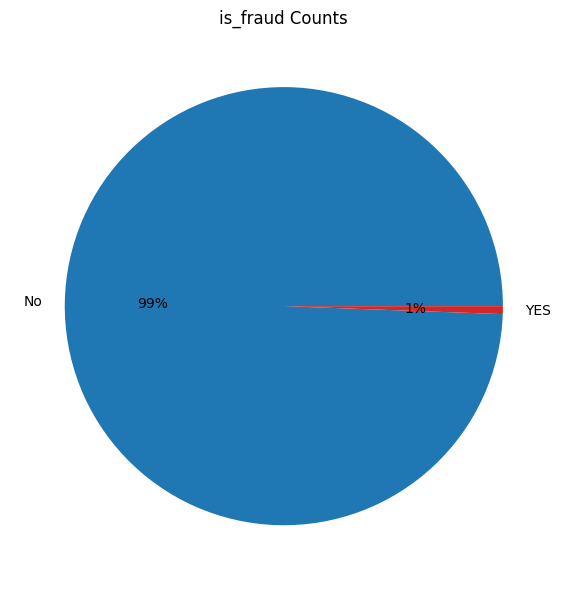

In [38]:
# Data Analysis and Visualization targe class
counts = df["is_fraud"].value_counts()
plt.figure(figsize=(12, 6))
plt.pie(counts, labels=["No", "YES"], colors=['tab:blue', 'tab:red'], autopct="%0.0f%%")
plt.title("is_fraud Counts")
plt.tight_layout()  # Adjust layout to prevent overlapping
plt.show()

In [39]:
# 5.1  IMBALANCE CHECK
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 70)
print("5.1  CLASS IMBALANCE CHECK")
print("=" * 70)
 
fraud_n   = int(y_train.sum())
legit_n   = int((y_train == 0).sum())
ratio_raw = legit_n / fraud_n
fpct      = y_train.mean() * 100

print(f"""
  Training set class distribution:
    Legitimate (0) : {legit_n:>10,}   ({100 - fpct:.2f}%)
    Fraud      (1) : {fraud_n:>10,}   ({fpct:.2f}%)
    Imbalance ratio: {ratio_raw:.0f} : 1   (legitimate : fraud)
 
  This is a SEVERE imbalance ({ratio_raw:.0f}:1).  Without correction:
    • The model defaults to predicting 'legitimate' for almost every row.
    • Accuracy appears very high (~{100-fpct:.1f}%) but fraud Recall ≈ 0.
    • F1-score and PR-AUC on the minority (fraud) class collapse entirely.
 
  Strategy: SMOTE  (Synthetic Minority Over-sampling Technique)
    • Generates synthetic fraud samples by interpolating in feature space
      between real fraud examples and their k-nearest neighbours.
    • Applied ONLY to X_train_final / y_train.
    • X_val_final and X_test_final are NEVER resampled — they represent
      the true real-world fraud rate for unbiased evaluation.
    • Target sampling ratio = 0.2  (1 fraud per 5 legitimate).
      Using 1:1 would create too many synthetic samples and risk
      over-smoothing the minority class boundary.
""")

5.1  CLASS IMBALANCE CHECK

  Training set class distribution:
    Legitimate (0) :    902,418   (99.42%)
    Fraud      (1) :      5,254   (0.58%)
    Imbalance ratio: 172 : 1   (legitimate : fraud)

  This is a SEVERE imbalance (172:1).  Without correction:
    • The model defaults to predicting 'legitimate' for almost every row.
    • Accuracy appears very high (~99.4%) but fraud Recall ≈ 0.
    • F1-score and PR-AUC on the minority (fraud) class collapse entirely.

  Strategy: SMOTE  (Synthetic Minority Over-sampling Technique)
    • Generates synthetic fraud samples by interpolating in feature space
      between real fraud examples and their k-nearest neighbours.
    • Applied ONLY to X_train_final / y_train.
    • X_val_final and X_test_final are NEVER resampled — they represent
      the true real-world fraud rate for unbiased evaluation.
    • Target sampling ratio = 0.2  (1 fraud per 5 legitimate).
      Using 1:1 would create too many synthetic samples and risk
      over-sm

In [40]:
# 5.2  SMOTE  (Solution for imbalance problem)
# ─────────────────────────────────────────────────────────────────────────────
 
print("=" * 70)
print("5.2  APPLY SMOTE  (X_train_final / y_train only)")
print("=" * 70)
sm = SMOTE(
    sampling_strategy=0.2,
    k_neighbors=5,
    random_state=42,
)

# X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
X_train_bal, y_train_bal = sm.fit_resample(X_train_final, y_train)
 
fraud_after = int(y_train_bal.sum())
legit_after = int((y_train_bal == 0).sum())
ratio_after = legit_after / fraud_after

print(f"""
  Before SMOTE:
    Legitimate : {legit_n:>10,}   Fraud : {fraud_n:>8,}   Ratio {ratio_raw:.0f}:1
 
  After SMOTE:
    Legitimate : {legit_after:>10,}   Fraud : {fraud_after:>8,}   Ratio {ratio_after:.1f}:1
    Synthetic fraud samples added : {fraud_after - fraud_n:,}
 
  Val / Test sets are UNCHANGED — they reflect the true real-world distribution.
""")
 

5.2  APPLY SMOTE  (X_train_final / y_train only)

  Before SMOTE:
    Legitimate :    902,418   Fraud :    5,254   Ratio 172:1

  After SMOTE:
    Legitimate :    902,418   Fraud :  180,483   Ratio 5.0:1
    Synthetic fraud samples added : 175,229

  Val / Test sets are UNCHANGED — they reflect the true real-world distribution.



### 1) Random Forest 

In [41]:
# 5.3  MODEL TRAINING
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 70)
print("5.3  MODEL TRAINING")
print("=" * 70)
print("""
  Algorithm : Random Forest Classifier

  Goal:
    Compare four different imbalance-handling strategies
    using the same validation set.

  Models:
    A) Original Imbalanced Data + No Class Weight
    B) Original Imbalanced Data + Class Weight
    C) SMOTE Balanced Data + No Class Weight
    D) SMOTE Balanced Data + Class Weight
""")


# ------------------------------------------------------------
# Base Random Forest Parameters
# ------------------------------------------------------------
BASE_PARAMS = dict(
    n_estimators     = 300,
    max_depth        = 15,
    min_samples_leaf = 20,
    n_jobs           = -1,
    random_state     = 42,
)


# ------------------------------------------------------------
# Model A: Imbalanced + No Class Weight
# ------------------------------------------------------------
print("  Training Model A (Imbalanced + No Weight)...", flush=True)

rf_imb_plain = RandomForestClassifier(
    **BASE_PARAMS,
    class_weight=None
)

rf_imb_plain.fit(X_train_final, y_train)


# ------------------------------------------------------------
# Model B: Imbalanced + Class Weight
# ------------------------------------------------------------
print("  Training Model B (Imbalanced + Class Weight)...", flush=True)

rf_imb_weight = RandomForestClassifier(
    **BASE_PARAMS,
    class_weight='balanced'
)

rf_imb_weight.fit(X_train_final, y_train)


# ------------------------------------------------------------
# Model C: SMOTE + No Class Weight
# ------------------------------------------------------------
print("  Training Model C (SMOTE + No Weight)...", flush=True)

rf_smote_plain = RandomForestClassifier(
    **BASE_PARAMS,
    class_weight=None
)

rf_smote_plain.fit(X_train_bal, y_train_bal)


# ------------------------------------------------------------
# Model D: SMOTE + Class Weight
# ------------------------------------------------------------
print("  Training Model D (SMOTE + Class Weight)...", flush=True)

rf_smote_weight = RandomForestClassifier(
    **BASE_PARAMS,
    class_weight='balanced'
)

rf_smote_weight.fit(X_train_bal, y_train_bal)


print("  All four models trained successfully.\n")

5.3  MODEL TRAINING

  Algorithm : Random Forest Classifier

  Goal:
    Compare four different imbalance-handling strategies
    using the same validation set.

  Models:
    A) Original Imbalanced Data + No Class Weight
    B) Original Imbalanced Data + Class Weight
    C) SMOTE Balanced Data + No Class Weight
    D) SMOTE Balanced Data + Class Weight

  Training Model A (Imbalanced + No Weight)...
  Training Model B (Imbalanced + Class Weight)...
  Training Model C (SMOTE + No Weight)...
  Training Model D (SMOTE + Class Weight)...
  All four models trained successfully.



In [42]:
# 5.4  EVALUATION
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 70)
print("5.4  EVALUATION ON VALIDATION SET  (never-seen, unbalanced)")
print("=" * 70)

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Evaluation Function
# ------------------------------------------------------------
def evaluate_model(model, X, y_true, label, threshold=0.5):

    # Predict probabilities
    proba = model.predict_proba(X)[:, 1]

    # Convert probability to class prediction
    pred = (proba >= threshold).astype(int)

    # Metrics
    cm = confusion_matrix(y_true, pred)
    roc = roc_auc_score(y_true, proba)
    pr_auc = average_precision_score(y_true, proba)

    # Classification report
    report = classification_report(
        y_true,
        pred,
        target_names=['Legitimate', 'Fraud'],
        digits=4,
        output_dict=True
    )

    # Print results
    print(f"\n{'─' * 65}")
    print(f"  {label}")
    print(f"{'─' * 65}")
    print(f"  ROC-AUC : {roc:.4f}")
    print(f"  PR-AUC  : {pr_auc:.4f}   ← primary metric for fraud data\n")

    print(classification_report(
        y_true,
        pred,
        target_names=['Legitimate', 'Fraud'],
        digits=4
    ))

    print(f"  Confusion Matrix (threshold = {threshold})")
    print(f"    TN = {cm[0,0]:>8,}   FP = {cm[0,1]:>7,}")
    print(f"    FN = {cm[1,0]:>8,}   TP = {cm[1,1]:>7,}")

    return {
        'label': label,
        'proba': proba,
        'cm': cm,
        'roc_auc': roc,
        'pr_auc': pr_auc,
        'report': report
    }


# ------------------------------------------------------------
# Evaluate Four Models
# ------------------------------------------------------------
results = []

results.append(
    evaluate_model(
        rf_imb_plain,
        X_val_final,
        y_val,
        "Model A — Imbalanced + No Weight"
    )
)

results.append(
    evaluate_model(
        rf_imb_weight,
        X_val_final,
        y_val,
        "Model B — Imbalanced + Class Weight"
    )
)

results.append(
    evaluate_model(
        rf_smote_plain,
        X_val_final,
        y_val,
        "Model C — SMOTE + No Weight"
    )
)

results.append(
    evaluate_model(
        rf_smote_weight,
        X_val_final,
        y_val,
        "Model D — SMOTE + Class Weight"
    )
)


5.4  EVALUATION ON VALIDATION SET  (never-seen, unbalanced)

─────────────────────────────────────────────────────────────────
  Model A — Imbalanced + No Weight
─────────────────────────────────────────────────────────────────
  ROC-AUC : 0.9960
  PR-AUC  : 0.8659   ← primary metric for fraud data

              precision    recall  f1-score   support

  Legitimate     0.9983    0.9997    0.9990    193375
       Fraud     0.9275    0.7043    0.8006      1126

    accuracy                         0.9980    194501
   macro avg     0.9629    0.8520    0.8998    194501
weighted avg     0.9979    0.9980    0.9978    194501

  Confusion Matrix (threshold = 0.5)
    TN =  193,313   FP =      62
    FN =      333   TP =     793

─────────────────────────────────────────────────────────────────
  Model B — Imbalanced + Class Weight
─────────────────────────────────────────────────────────────────
  ROC-AUC : 0.9965
  PR-AUC  : 0.8636   ← primary metric for fraud data

              precision  

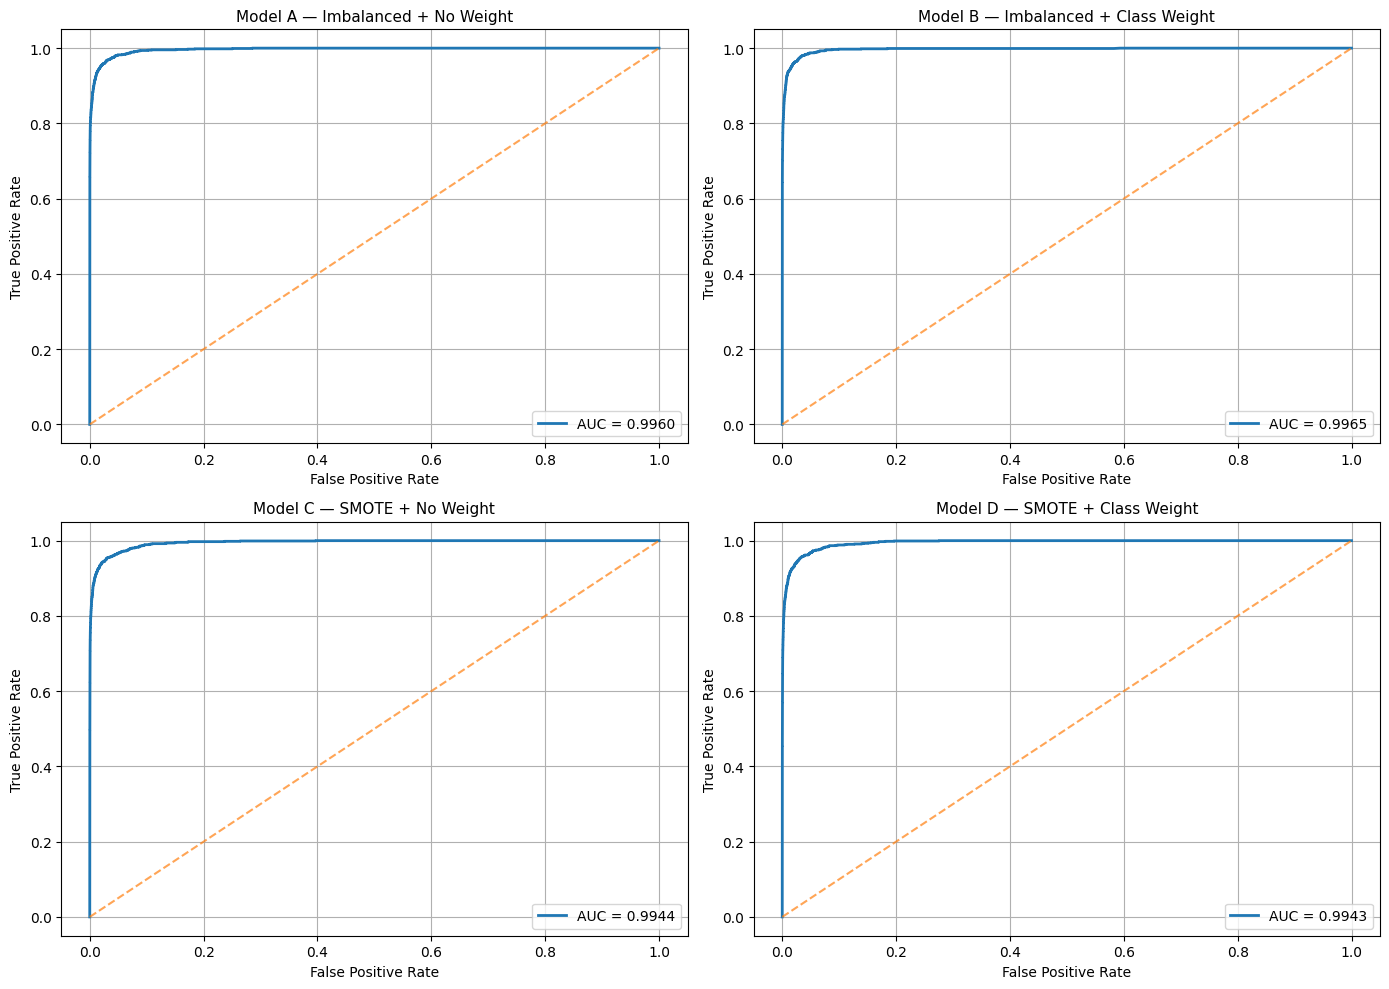

In [43]:
# ------------------------------------------------------------
# ROC Curve Visualization (2x2 Grid - One Plot Per Model)
# ------------------------------------------------------------
%matplotlib inline

plt.figure(figsize=(14, 10))

for i, res in enumerate(results, 1):

    # Create subplot position
    plt.subplot(2, 2, i)

    # ROC values
    fpr, tpr, _ = roc_curve(y_val, res['proba'])

    # Plot ROC curve
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"AUC = {res['roc_auc']:.4f}"
    )

    # Random classifier line
    plt.plot([0, 1], [0, 1], linestyle='--', alpha=0.7)

    # Titles and labels
    plt.title(res['label'], fontsize=11)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    # Styling
    plt.legend(loc='lower right')
    plt.grid(True)

# Adjust layout
plt.tight_layout()
plt.show()

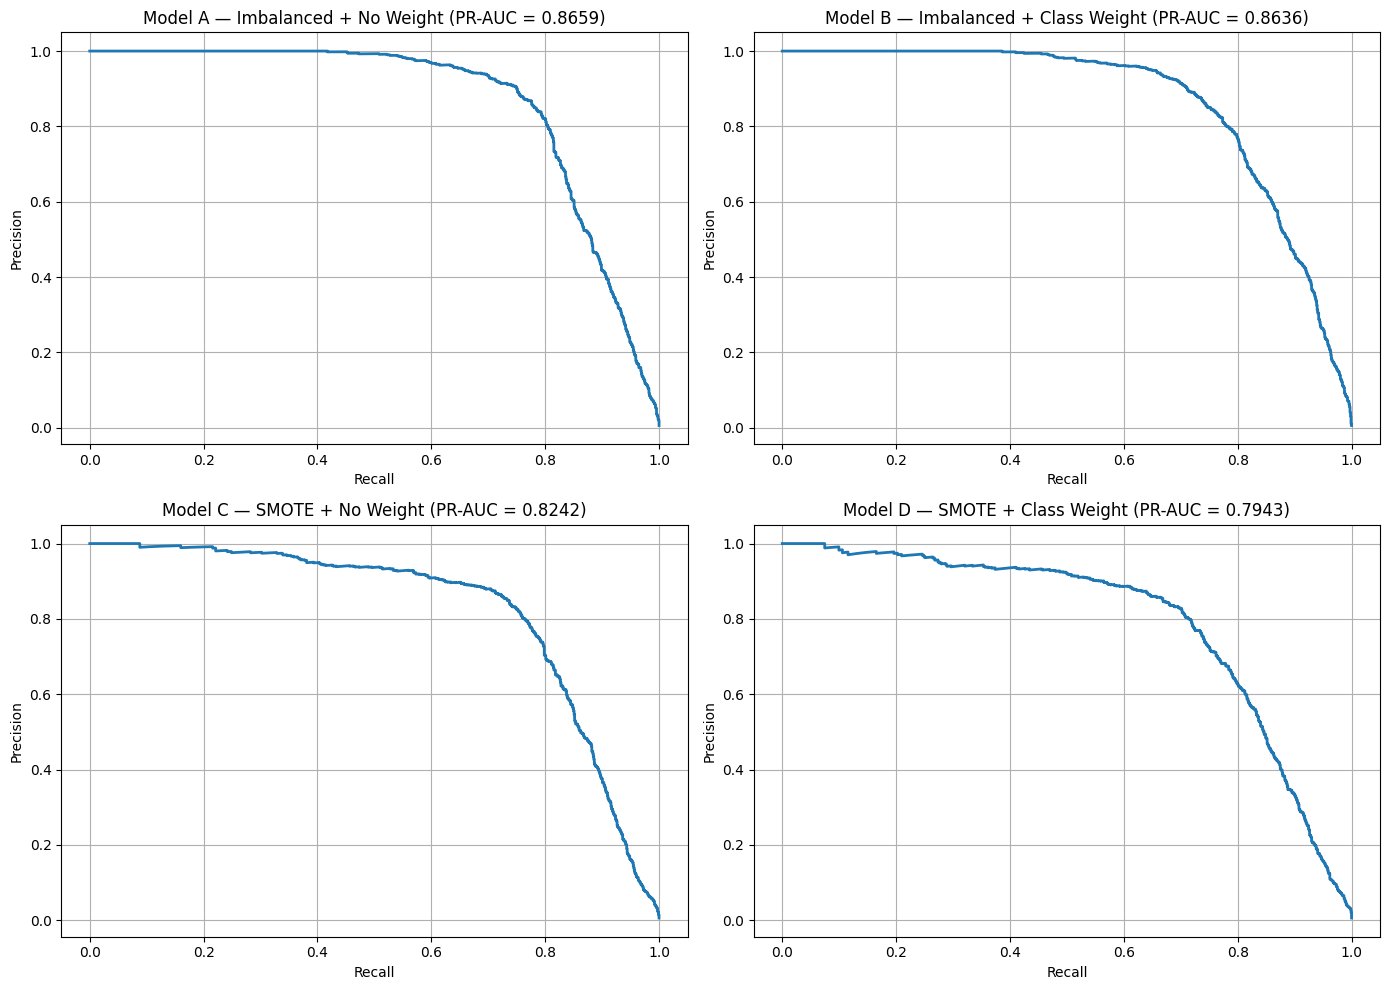

In [44]:
# ------------------------------------------------------------ 
# Precision-Recall Curve Visualization (2x2 Subplots)
# ------------------------------------------------------------ 
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, res in enumerate(results):
    precision, recall, _ = precision_recall_curve(y_val, res['proba'])

    axes[i].plot(recall, precision, linewidth=2)
    axes[i].set_title(f"{res['label']} (PR-AUC = {res['pr_auc']:.4f})")
    axes[i].set_xlabel("Recall")
    axes[i].set_ylabel("Precision")
    axes[i].grid(True)


for j in range(len(results), 4):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [45]:
# 5.5  COMPARISON SUMMARY (4 Models)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 95)
print("5.5  COMPARISON SUMMARY")
print("=" * 95)

# ------------------------------------------------------------
# Convert results list into dictionary for easier access
# ------------------------------------------------------------
res_dict = {res['label']: res for res in results}

# ------------------------------------------------------------
# Build comparison table
# ------------------------------------------------------------
comparison = {
    'ROC-AUC': [
        res_dict["Model A — Imbalanced + No Weight"]['roc_auc'],
        res_dict["Model B — Imbalanced + Class Weight"]['roc_auc'],
        res_dict["Model C — SMOTE + No Weight"]['roc_auc'],
        res_dict["Model D — SMOTE + Class Weight"]['roc_auc'],
    ],

    'PR-AUC': [
        res_dict["Model A — Imbalanced + No Weight"]['pr_auc'],
        res_dict["Model B — Imbalanced + Class Weight"]['pr_auc'],
        res_dict["Model C — SMOTE + No Weight"]['pr_auc'],
        res_dict["Model D — SMOTE + Class Weight"]['pr_auc'],
    ],

    'Fraud Precision': [
        res_dict["Model A — Imbalanced + No Weight"]['report']['Fraud']['precision'],
        res_dict["Model B — Imbalanced + Class Weight"]['report']['Fraud']['precision'],
        res_dict["Model C — SMOTE + No Weight"]['report']['Fraud']['precision'],
        res_dict["Model D — SMOTE + Class Weight"]['report']['Fraud']['precision'],
    ],

    'Fraud Recall': [
        res_dict["Model A — Imbalanced + No Weight"]['report']['Fraud']['recall'],
        res_dict["Model B — Imbalanced + Class Weight"]['report']['Fraud']['recall'],
        res_dict["Model C — SMOTE + No Weight"]['report']['Fraud']['recall'],
        res_dict["Model D — SMOTE + Class Weight"]['report']['Fraud']['recall'],
    ],

    'Fraud F1': [
        res_dict["Model A — Imbalanced + No Weight"]['report']['Fraud']['f1-score'],
        res_dict["Model B — Imbalanced + Class Weight"]['report']['Fraud']['f1-score'],
        res_dict["Model C — SMOTE + No Weight"]['report']['Fraud']['f1-score'],
        res_dict["Model D — SMOTE + Class Weight"]['report']['Fraud']['f1-score'],
    ],

    'Legit Precision': [
        res_dict["Model A — Imbalanced + No Weight"]['report']['Legitimate']['precision'],
        res_dict["Model B — Imbalanced + Class Weight"]['report']['Legitimate']['precision'],
        res_dict["Model C — SMOTE + No Weight"]['report']['Legitimate']['precision'],
        res_dict["Model D — SMOTE + Class Weight"]['report']['Legitimate']['precision'],
    ],

    'Legit Recall': [
        res_dict["Model A — Imbalanced + No Weight"]['report']['Legitimate']['recall'],
        res_dict["Model B — Imbalanced + Class Weight"]['report']['Legitimate']['recall'],
        res_dict["Model C — SMOTE + No Weight"]['report']['Legitimate']['recall'],
        res_dict["Model D — SMOTE + Class Weight"]['report']['Legitimate']['recall'],
    ]
}

# ------------------------------------------------------------
# Print Header
# ------------------------------------------------------------
print(f"\n{'Metric':<20} {'Model A':>12} {'Model B':>12} {'Model C':>12} {'Model D':>12}")
print("─" * 72)

# ------------------------------------------------------------
# Print Metrics
# ------------------------------------------------------------
for metric, values in comparison.items():
    print(
        f"{metric:<20} "
        f"{values[0]:>12.4f} "
        f"{values[1]:>12.4f} "
        f"{values[2]:>12.4f} "
        f"{values[3]:>12.4f}"
    )


5.5  COMPARISON SUMMARY

Metric                    Model A      Model B      Model C      Model D
────────────────────────────────────────────────────────────────────────
ROC-AUC                    0.9960       0.9965       0.9944       0.9943
PR-AUC                     0.8659       0.8636       0.8242       0.7943
Fraud Precision            0.9275       0.4439       0.7541       0.4627
Fraud Recall               0.7043       0.9067       0.7842       0.8544
Fraud F1                   0.8006       0.5960       0.7688       0.6003
Legit Precision            0.9983       0.9995       0.9987       0.9991
Legit Recall               0.9997       0.9934       0.9985       0.9942


In [46]:
# 5.8  FINAL TEST-SET EVALUATION  (run only once — at the very end)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("5.8  FINAL TEST-SET EVALUATION  (best model on held-out test)")
print("=" * 70)
 
# Use the SMOTE-balanced model (if it outperformed the baseline on val)
proba_test = rf_imb_weight.predict_proba(X_test_final)[:, 1]
pred_test  = (proba_test >= 0.5).astype(int)
 
print(f"""
  Model     : Random Forest — SMOTE-balanced
  Test ROC-AUC  : {roc_auc_score(y_test, proba_test):.4f}
  Test PR-AUC   : {average_precision_score(y_test, proba_test):.4f}
""")
print(classification_report(
    y_test, pred_test,
    target_names=['Legitimate', 'Fraud'], digits=4,
))
 
print("""
NOTES & NEXT STEPS
───────────────────
1. Threshold tuning:
   The default threshold of 0.5 may not be optimal for fraud detection.
   Plot the PR curve and choose a threshold that matches your business
   cost ratio:  cost(FN missed fraud) vs cost(FP blocked legitimate).
   E.g., lowering to 0.3 increases Recall at the cost of Precision.
 
2. Alternative balancing strategies:
   • Class weights alone (class_weight='balanced') — fastest, no synthetic data.
   • SMOTE + Tomek Links — remove borderline majority samples after oversampling.
   • ADASYN — generates more synthetic samples in harder-to-learn regions.
 
3. Next model candidates:
   • LightGBM with scale_pos_weight — handles 1.3M rows faster than RF.
   • XGBoost with eval_metric='aucpr' — optimises directly for PR-AUC.
   • Isolation Forest — unsupervised anomaly detection as a complementary signal.
 
4. Model interpretability:
   • SHAP values on rf_bal to explain individual fraud predictions.
   • Partial dependence plots for amt, geo_distance, trans_hour.
""")


5.8  FINAL TEST-SET EVALUATION  (best model on held-out test)

  Model     : Random Forest — SMOTE-balanced
  Test ROC-AUC  : 0.9961
  Test PR-AUC   : 0.8771

              precision    recall  f1-score   support

  Legitimate     0.9995    0.9937    0.9966    193376
       Fraud     0.4581    0.9174    0.6111      1126

    accuracy                         0.9932    194502
   macro avg     0.7288    0.9555    0.8038    194502
weighted avg     0.9964    0.9932    0.9944    194502


NOTES & NEXT STEPS
───────────────────
1. Threshold tuning:
   The default threshold of 0.5 may not be optimal for fraud detection.
   Plot the PR curve and choose a threshold that matches your business
   cost ratio:  cost(FN missed fraud) vs cost(FP blocked legitimate).
   E.g., lowering to 0.3 increases Recall at the cost of Precision.

2. Alternative balancing strategies:
   • Class weights alone (class_weight='balanced') — fastest, no synthetic data.
   • SMOTE + Tomek Links — remove borderline majorit

### 2) LGBMClassifier with  SMOTETomek 

In [ ]:
# 5.3  MODEL TRAINING
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 70)
print("5.3  MODEL TRAINING")
print("=" * 70)
print("""
Algorithm : LightGBM Classifier

Goal:
  Compare two strong imbalance-handling strategies
  using the same validation set.

Models:
  A) Original Imbalanced Data + Class Weight
  B) SMOTETomek Balanced Data
""")

from lightgbm import LGBMClassifier
from imblearn.combine import SMOTETomek


# ------------------------------------------------------------
# Create SMOTETomek Resampled Training Set
# ------------------------------------------------------------
print("  Applying SMOTETomek on training data...", flush=True)

smt = SMOTETomek(
    sampling_strategy=0.2,
    random_state=42
)

X_train_tomek, y_train_tomek = smt.fit_resample(X_train_final, y_train)


# ------------------------------------------------------------
# Base LightGBM Parameters
# ------------------------------------------------------------
BASE_PARAMS = dict(
    n_estimators      = 500,
    learning_rate     = 0.05,
    max_depth         = 8,
    num_leaves        = 31,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    # n_jobs            = -1,
    random_state      = 42
)


# ------------------------------------------------------------
# Model A: Imbalanced + Class Weight
# ------------------------------------------------------------
print("  Training Model A (Imbalanced + Class Weight)...", flush=True)

lgbm_weight = LGBMClassifier(
    **BASE_PARAMS,
    class_weight='balanced'
)

lgbm_weight.fit(X_train_final, y_train)


# ------------------------------------------------------------
# Model B: SMOTETomek Balanced
# ------------------------------------------------------------
print("  Training Model B (SMOTETomek)...", flush=True)

lgbm_tomek = LGBMClassifier(
    **BASE_PARAMS,
    class_weight=None
)

lgbm_tomek.fit(X_train_tomek, y_train_tomek)


print("  Both LightGBM models trained successfully.\n")

5.3  MODEL TRAINING

Algorithm : LightGBM Classifier

Goal:
  Compare two strong imbalance-handling strategies
  using the same validation set.

Models:
  A) Original Imbalanced Data + Class Weight
  B) SMOTETomek Balanced Data

  Applying SMOTETomek on training data...
  Training Model A (Imbalanced + Class Weight)...
[LightGBM] [Info] Number of positive: 5254, number of negative: 902418
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017156 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1206
[LightGBM] [Info] Number of data points in the train set: 907672, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
  Training Model B (SMOTETomek)...
[LightGBM] [Info] Number of positive: 179342, number of negative: 901277
[LightGBM] [

In [ ]:
# 5.3  MODEL TRAINING
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 70)
print("5.3  MODEL TRAINING")
print("=" * 70)
print("""
Algorithm : LightGBM Classifier
Goal:
  Compare two strong imbalance-handling strategies
  using the same validation set.
Models:
  A) Original Imbalanced Data + Class Weight
  B) SMOTETomek Balanced Data (categorical-aware)
""")
from lightgbm import LGBMClassifier
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTENC

# ------------------------------------------------------------
# Categorical Feature Indices (for SMOTENC inside SMOTETomek)
# ------------------------------------------------------------
CATEGORICAL_FEATURES = ['gender_enc', 'category_enc', 'is_weekend', 'is_night', 'pop_bin']

cat_feature_indices = [
    X_train_final.columns.get_loc(col)
    for col in CATEGORICAL_FEATURES
    if col in X_train_final.columns
]

print(f"  Categorical feature indices passed to SMOTENC: {cat_feature_indices}", flush=True)

# ------------------------------------------------------------
# Create SMOTETomek Resampled Training Set (categorical-aware)
# ------------------------------------------------------------
print("  Applying SMOTETomek (with SMOTENC) on training data...", flush=True)
smt = SMOTETomek(
    smote=SMOTENC(
        categorical_features=cat_feature_indices,
        sampling_strategy=0.2,
        random_state=42
    ),
    random_state=42
)
X_train_tomek, y_train_tomek = smt.fit_resample(X_train_final, y_train)

# ------------------------------------------------------------
# Base LightGBM Parameters
# ------------------------------------------------------------
BASE_PARAMS = dict(
    n_estimators      = 500,
    learning_rate     = 0.05,
    max_depth         = 8,
    num_leaves        = 31,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    # n_jobs            = -1,
    random_state      = 42
)

# ------------------------------------------------------------
# Model A: Imbalanced + Class Weight
# ------------------------------------------------------------
print("  Training Model A (Imbalanced + Class Weight)...", flush=True)
lgbm_weight = LGBMClassifier(
    **BASE_PARAMS,
    class_weight='balanced'
)
lgbm_weight.fit(X_train_final, y_train)

# ------------------------------------------------------------
# Model B: SMOTETomek Balanced (categorical-aware)
# ------------------------------------------------------------
print("  Training Model B (SMOTETomek + SMOTENC)...", flush=True)
lgbm_tomek = LGBMClassifier(
    **BASE_PARAMS,
    class_weight=None
)
lgbm_tomek.fit(X_train_tomek, y_train_tomek)
print("  Both LightGBM models trained successfully.\n")

In [71]:
# 5.4  EVALUATION
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 70)
print("5.4  EVALUATION ON VALIDATION SET  (never-seen, unbalanced)")
print("=" * 70)

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Evaluation Function
# ------------------------------------------------------------
def evaluate_model(model, X, y_true, label, threshold=0.5):

    proba = model.predict_proba(X)[:, 1]
    pred  = (proba >= threshold).astype(int)

    cm     = confusion_matrix(y_true, pred)
    roc    = roc_auc_score(y_true, proba)
    pr_auc = average_precision_score(y_true, proba)

    report = classification_report(
        y_true, pred,
        target_names=['Legitimate', 'Fraud'],
        digits=4,
        output_dict=True
    )

    print(f"\n{'─' * 65}")
    print(f"  {label}")
    print(f"{'─' * 65}")
    print(f"  ROC-AUC : {roc:.4f}")
    print(f"  PR-AUC  : {pr_auc:.4f}   ← primary metric for fraud data\n")
    print(classification_report(
        y_true, pred,
        target_names=['Legitimate', 'Fraud'],
        digits=4
    ))
    print(f"  Confusion Matrix (threshold = {threshold})")
    print(f"    TN = {cm[0,0]:>8,}   FP = {cm[0,1]:>7,}")
    print(f"    FN = {cm[1,0]:>8,}   TP = {cm[1,1]:>7,}")

    return {
        'label'  : label,
        'proba'  : proba,
        'cm'     : cm,
        'roc_auc': roc,
        'pr_auc' : pr_auc,
        'report' : report
    }


# ------------------------------------------------------------
# Evaluate All 6 Models
# ------------------------------------------------------------
results = []

# --- Random Forest (Models A–D) ---
results.append(evaluate_model(
    rf_imb_plain,   X_val_final, y_val,
    "Model A — Random Forest  |  Imbalanced + No Weight"
))
results.append(evaluate_model(
    rf_imb_weight,  X_val_final, y_val,
    "Model B — Random Forest  |  Imbalanced + Class Weight"
))
results.append(evaluate_model(
    rf_smote_plain, X_val_final, y_val,
    "Model C — Random Forest  |  SMOTE + No Weight"
))
results.append(evaluate_model(
    rf_smote_weight, X_val_final, y_val,
    "Model D — Random Forest  |  SMOTE + Class Weight"
))

# --- LightGBM (Models E–F) ---
results.append(evaluate_model(
    lgbm_weight, X_val_final, y_val,
    "Model E — LightGBM  |  Imbalanced + Class Weight"
))
results.append(evaluate_model(
    lgbm_tomek,  X_val_final, y_val,
    "Model F — LightGBM  |  SMOTETomek Balanced"
))


# ─────────────────────────────────────────────────────────────────────────────
# 5.5  COMPARISON SUMMARY (6 Models)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 110)
print("5.5  COMPARISON SUMMARY")
print("=" * 110)

# ------------------------------------------------------------
# Convert results list into dictionary for easier access
# ------------------------------------------------------------
res_dict = {res['label']: res for res in results}

MODEL_LABELS = [
    "Model A — Random Forest  |  Imbalanced + No Weight",
    "Model B — Random Forest  |  Imbalanced + Class Weight",
    "Model C — Random Forest  |  SMOTE + No Weight",
    "Model D — Random Forest  |  SMOTE + Class Weight",
    "Model E — LightGBM  |  Imbalanced + Class Weight",
    "Model F — LightGBM  |  SMOTETomek Balanced",
]

SHORT_NAMES = ["Model A", "Model B", "Model C", "Model D", "Model E", "Model F"]

# ------------------------------------------------------------
# Build comparison table
# ------------------------------------------------------------
METRICS = {
    'ROC-AUC'        : lambda r: r['roc_auc'],
    'PR-AUC'         : lambda r: r['pr_auc'],
    'Fraud Precision': lambda r: r['report']['Fraud']['precision'],
    'Fraud Recall'   : lambda r: r['report']['Fraud']['recall'],
    'Fraud F1'       : lambda r: r['report']['Fraud']['f1-score'],
    'Legit Precision': lambda r: r['report']['Legitimate']['precision'],
    'Legit Recall'   : lambda r: r['report']['Legitimate']['recall'],
}

5.4  EVALUATION ON VALIDATION SET  (never-seen, unbalanced)

─────────────────────────────────────────────────────────────────
  Model A — Random Forest  |  Imbalanced + No Weight
─────────────────────────────────────────────────────────────────
  ROC-AUC : 0.9960
  PR-AUC  : 0.8659   ← primary metric for fraud data

              precision    recall  f1-score   support

  Legitimate     0.9983    0.9997    0.9990    193375
       Fraud     0.9275    0.7043    0.8006      1126

    accuracy                         0.9980    194501
   macro avg     0.9629    0.8520    0.8998    194501
weighted avg     0.9979    0.9980    0.9978    194501

  Confusion Matrix (threshold = 0.5)
    TN =  193,313   FP =      62
    FN =      333   TP =     793

─────────────────────────────────────────────────────────────────
  Model B — Random Forest  |  Imbalanced + Class Weight
─────────────────────────────────────────────────────────────────
  ROC-AUC : 0.9965
  PR-AUC  : 0.8636   ← primary metric for f

In [73]:
# ------------------------------------------------------------
# Print legend
# ------------------------------------------------------------
print()
for short, label in zip(SHORT_NAMES, MODEL_LABELS):
    print(f"  {short} :  {label}")
# ------------------------------------------------------------
# Print header
# ------------------------------------------------------------
header = f"\n{'Metric':<20}" + "".join(f"{s:>12}" for s in SHORT_NAMES)
print(header)
print("─" * (20 + 12 * len(SHORT_NAMES)))
# ------------------------------------------------------------
# Print each metric row
# ------------------------------------------------------------
for metric_name, extractor in METRICS.items():
    values = [extractor(res_dict[lbl]) for lbl in MODEL_LABELS]
    row = f"{metric_name:<20}" + "".join(f"{v:>12.4f}" for v in values)
    print(row)


  Model A :  Model A — Random Forest  |  Imbalanced + No Weight
  Model B :  Model B — Random Forest  |  Imbalanced + Class Weight
  Model C :  Model C — Random Forest  |  SMOTE + No Weight
  Model D :  Model D — Random Forest  |  SMOTE + Class Weight
  Model E :  Model E — LightGBM  |  Imbalanced + Class Weight
  Model F :  Model F — LightGBM  |  SMOTETomek Balanced

Metric                   Model A     Model B     Model C     Model D     Model E     Model F
────────────────────────────────────────────────────────────────────────────────────────────
ROC-AUC                   0.9960      0.9965      0.9944      0.9943      0.9984      0.9971
PR-AUC                    0.8659      0.8636      0.8242      0.7943      0.9242      0.9094
Fraud Precision           0.9275      0.4439      0.7541      0.4627      0.3836      0.9284
Fraud Recall              0.7043      0.9067      0.7842      0.8544      0.9574      0.8171
Fraud F1                  0.8006      0.5960      0.7688      0.6003  

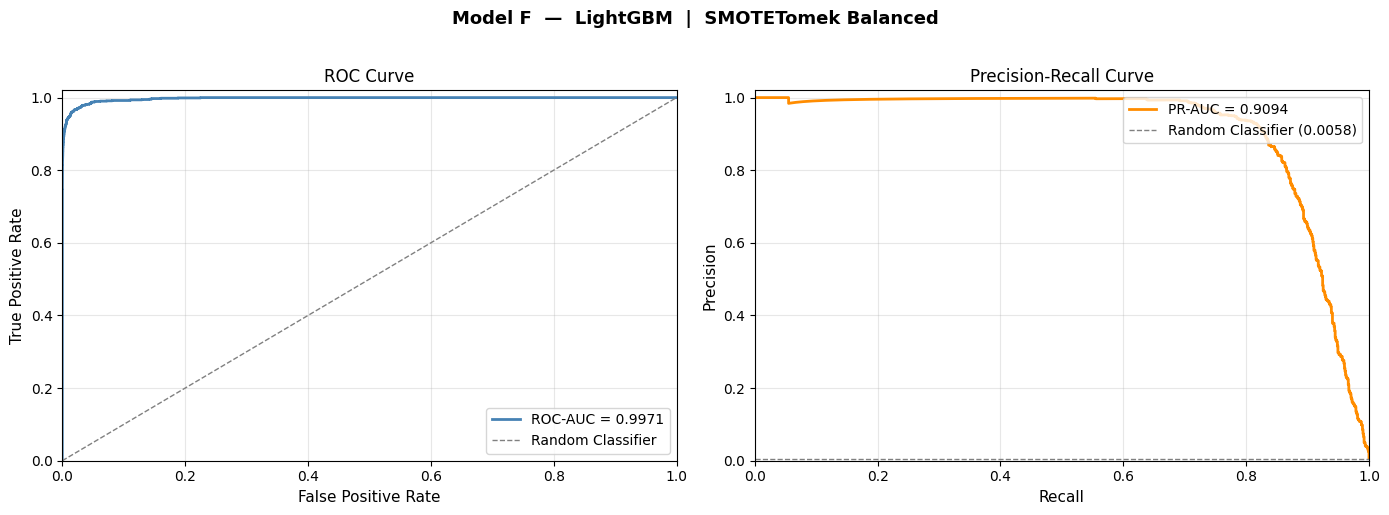

In [74]:
## Best Model is F
# ─────────────────────────────────────────────────────────────────────────────
# ROC Curve & PR Curve — Model F (LightGBM | SMOTETomek Balanced)
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score
import matplotlib.pyplot as plt

# Retrieve Model F results
model_f = res_dict["Model F — LightGBM  |  SMOTETomek Balanced"]
proba_f = model_f['proba']

# Compute curves
fpr, tpr, _         = roc_curve(y_val, proba_f)
precision, recall, _ = precision_recall_curve(y_val, proba_f)

roc_auc = model_f['roc_auc']
pr_auc  = model_f['pr_auc']

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model F  —  LightGBM  |  SMOTETomek Balanced", fontsize=13, fontweight='bold', y=1.02)

# --- ROC Curve ---
ax = axes[0]
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f"ROC-AUC = {roc_auc:.4f}")
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label="Random Classifier")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("ROC Curve", fontsize=12)
ax.legend(loc="lower right", fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

# --- PR Curve ---
ax = axes[1]
baseline = y_val.sum() / len(y_val)          # fraud prevalence
ax.plot(recall, precision, color='darkorange', lw=2, label=f"PR-AUC = {pr_auc:.4f}")
ax.axhline(baseline, color='gray', lw=1, linestyle='--', label=f"Random Classifier ({baseline:.4f})")
ax.set_xlabel("Recall", fontsize=11)
ax.set_ylabel("Precision", fontsize=11)
ax.set_title("Precision-Recall Curve", fontsize=12)
ax.legend(loc="upper right", fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.show()

In [75]:
# 5.8  FINAL TEST-SET EVALUATION  (run only once — at the very end)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("5.8  FINAL TEST-SET EVALUATION  (best model on held-out test)")
print("=" * 70)

# Model F — LightGBM | SMOTETomek Balanced
proba_test = lgbm_tomek.predict_proba(X_test_final)[:, 1]
pred_test  = (proba_test >= 0.5).astype(int)

print(f"""
  Model         : LightGBM — SMOTETomek Balanced
  Test ROC-AUC  : {roc_auc_score(y_test, proba_test):.4f}
  Test PR-AUC   : {average_precision_score(y_test, proba_test):.4f}
""")
print(classification_report(
    y_test, pred_test,
    target_names=['Legitimate', 'Fraud'], digits=4,
))


5.8  FINAL TEST-SET EVALUATION  (best model on held-out test)

  Model         : LightGBM — SMOTETomek Balanced
  Test ROC-AUC  : 0.9959
  Test PR-AUC   : 0.9123

              precision    recall  f1-score   support

  Legitimate     0.9990    0.9996    0.9993    193376
       Fraud     0.9299    0.8242    0.8738      1126

    accuracy                         0.9986    194502
   macro avg     0.9644    0.9119    0.9366    194502
weighted avg     0.9986    0.9986    0.9986    194502

